# Introduction

In the Tutorial 3, *"Physical Congestion"* we looked at the effect of distributed renewable generation on the distribution grid, and how storage and peak shaving reduces this effect. In this tutorial we focus on evaluating the positive influence of energy hubs. TODO UPDATE THIS ONCE WE DECIDE

An energy hub is a smartly-controlled decentralized energy system within a defined area coordinating their generation, storage, conversion, and consumption to balance the local demand and collaborating towards a common goal.

One of the main advantages of an energy hub is the flexibility of generation and demand. Generation can be tailored to the more specific local needs, and demand can be handled by peak shifting (cooperation) and appropriate storage strategy.

First of all lets install the necessary packages for the visualizations in this tutorial by running the next cell:

## Setup

Run the following 2 cells and wait for them to execute, they will install and import all necessary packages for this notebook.

In [1]:
%pip install -q ipywidgets
%pip install ipympl
%pip install matplotlib 
%matplotlib widget

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from illuminator.engine import Simulation
import pandas as pd
import nest_asyncio
nest_asyncio.apply()

# TODO: When done move everything to one helper py script file

from energy_dashboard_function import run_energy_dashboard
from combined_analysis_plots import plot_combined_analysis 
from electricity_cost_calculator import calculate_electricity_cost
from complete_co2_workflow import align_dates_and_calculate_co2


## Part I: Baseline Scenario
We will start by looking into a scenario of 100 households with no renewables installed. 

## KPIs
Key Performance Indicators (KPIs) help us evaluate and compare different scenarios. In this tutorial we will be using the following KPIs:
- **CO2 emissions** as a measure for sustainability
- **Cost** as a measure of efficiency and 
- **Grid congestion events** as a measure for distribution efficiency.

### Running the Baseline scenario
The following cell runs an Illuminator simulation of the 100 households w ementioned above. Run the following 4 dates, which ones are problematic?
Note that the Windy & Sunny characteristics of the days play no role yet, as we are not yet utilising renewables. They will come in handy later in the tutorial.

In [3]:
%%capture
CONFIG_FILE = 'data\Tutorial_5.yaml'
simulation = Simulation(CONFIG_FILE)

#         ---- Not Windy not Sunny ----
simulation.set_scenario_param('start_time', '2012-01-01 00:00:00')
simulation.set_scenario_param('end_time', '2012-01-01 23:45:00')

#         ---- Windy not Sunny ----
# simulation.set_scenario_param('start_time', '2012-01-08 00:00:00')
# simulation.set_scenario_param('end_time', '2012-01-08 23:45:00')

#        ---- Sunny not Windy -----
# simulation.set_scenario_param('start_time', '2012-06-09 00:00:00')
# simulation.set_scenario_param('end_time', '2012-06-09 23:45:00')

#         ---- Sunny & Windy -----
# simulation.set_scenario_param('start_time', '2012-06-07 00:00:00')
# simulation.set_scenario_param('end_time', '2012-06-07 23:45:00')

# run the simulation
simulation.run()

2026-01-28 16:34:17.158 | INFO     | mosaik.async_scenario:start:508 - Starting 'Collector-0' (based on starter 'Collector')
2026-01-28 16:34:18.424 | INFO     | mosaik.async_scenario:start:508 - Starting 'CSVload-0' (based on starter 'CSVload')
2026-01-28 16:34:18.484 | WARNING  | mosaik.async_scenario:user_warning:360 - c:\Users\dgeorgiadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\mosaik\adapters.py:120: UserWarning: Simulator CSVload-0 is using an outdated API version, namely 1. It should still work. You can suppress this warning by adding an explicit API version for this simulator in your SimConfig.
2026-01-28 16:34:18.485 | INFO     | mosaik.async_scenario:start:508 - Starting 'CSV_pv-0' (based on starter 'CSV_pv')
2026-01-28 16:34:18.486 | WARNING  | mosaik.async_scenario:user_warning:360 - c:\Users\dgeorgiadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\mosaik\adapters.py:120: UserWarning: Simulator CSV_pv-0 is using an outdated API version, namely 1

### Evaluation
As we now don't generate with any renewables of our own we are tied to the CO2 production of the Netherlands' grid energy mix. We apply a (variable) CO2 calculation to the power demand, this will be the first KPI.  

We do a similar process to find the effect on cost of electricity, using the intraday market prices for the energy from the grid:

In [ ]:
# Calculate CO2 for baseline scenario
co2_results = align_dates_and_calculate_co2(
    consumption_file='out_Tutorial_5.csv',
    output_csv='co2_results.csv'
)
# Calculate electricity costs for baseline scenario
cost_results = calculate_electricity_cost(
    consumption_file='out_Tutorial_5.csv',
    output_csv='electricity_cost_results.csv'
)

Total CO2 Emissions:        193.83 kg
                            0.19 tonnes
  Total Cost:               €75.02

✓ Results saved to: electricity_cost_results.csv


Let's visualise these KPIs by running the cell below. Why do you think the plots look so similar?  


⚠ Grid congestion detected!
   Congestion events: 3


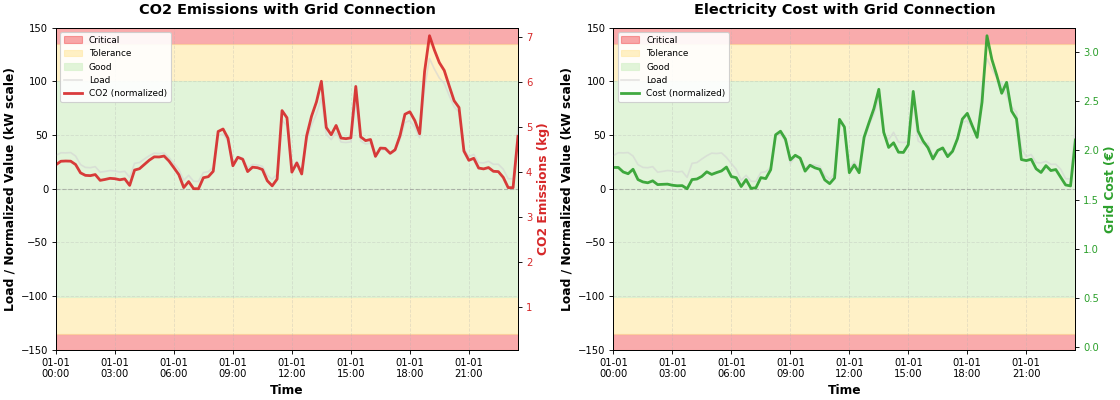

In [5]:
fig, (ax1, ax2) = plot_combined_analysis(
    co2_results_file='co2_results.csv',
    cost_results_file='electricity_cost_results.csv',
    consumption_file='out_Tutorial_5.csv',
    connection_cap=150,
    critical_limit=0.9,
    tolerance_limit=0.67,
    figsize=(14, 5)  # You can adjust this if needed
)

## Part II: Renewables
Run the widget below and move the sliders to select the amount of photovoltaic panels, medium wind turbines and storage capacity. Note that this estimation takes the best case output for these technologies.

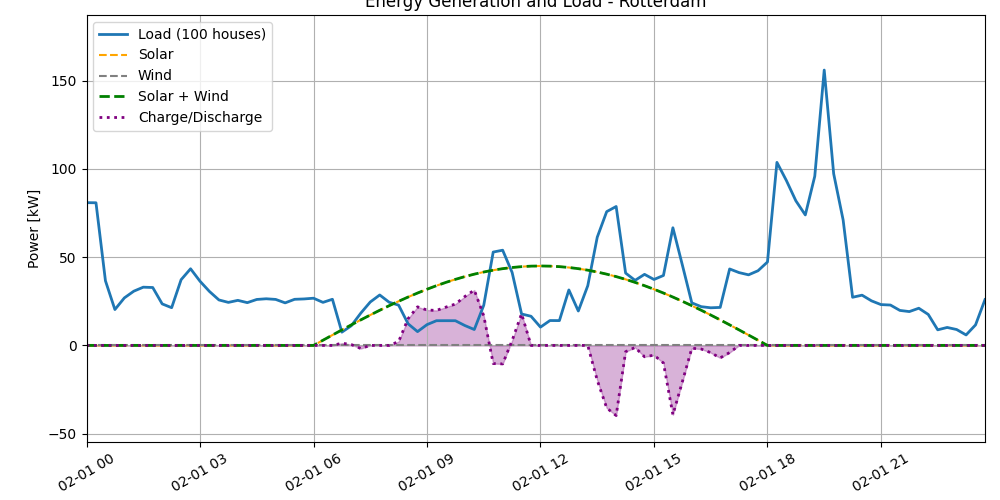

In [ ]:
dashboard = run_energy_dashboard()

Your settings above will automatically be applied to an Illuminator simulation on the cell below, make sure to choose the date that matches your baseline scenario!

In [7]:
%%capture
from Slider_set_simulation import run_res_simulation
sim, re_settings, df = run_res_simulation(dashboard)  
sim.edit_models(re_settings)

#         ---- Not Windy not Sunny ----
# Can get:
# Total CO2 Emissions:        153.70 kg
#                             0.15 tonnes
#   Total Cost:               €60.66
#     (Used renewables & grid, got congestion)
sim.set_scenario_param('start_time', '2012-01-01 00:00:00')
sim.set_scenario_param('end_time', '2012-01-01 23:45:00')

#         ---- Windy not Sunny ----
# Can get:
# Total CO2 Emissions:        0.00 kg
#                             0.00 tonnes
#   Total Cost:               €-274.23
#          (Used renewables only)
# sim.set_scenario_param('start_time', '2012-01-08 00:00:00')
# sim.set_scenario_param('end_time', '2012-01-08 23:45:00')

#        ---- Sunny not Windy -----
# Can get:
# Total CO2 Emissions:        84.97 kg
#                             0.08 tonnes
#   Total Cost:               €30.03
#      (Used renewables & grid, no congestion)
# sim.set_scenario_param('start_time', '2012-06-09 00:00:00')
# sim.set_scenario_param('end_time', '2012-06-09 23:45:00')


#         ---- Sunny & Windy -----
# Can get:
# Total CO2 Emissions:        0.00 kg
#                             0.00 tonnes
#   Total Cost:               €-221.21
#          (Used renewables only)
#
# sim.set_scenario_param('start_time', '2012-06-07 00:00:00')
# sim.set_scenario_param('end_time', '2012-06-07 23:45:00')


sim.run()


2026-01-28 16:34:22.943 | INFO     | mosaik.async_scenario:start:508 - Starting 'Collector-0' (based on starter 'Collector')
2026-01-28 16:34:24.138 | INFO     | mosaik.async_scenario:start:508 - Starting 'CSVload-0' (based on starter 'CSVload')
2026-01-28 16:34:24.142 | WARNING  | mosaik.async_scenario:user_warning:360 - c:\Users\dgeorgiadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\mosaik\adapters.py:120: UserWarning: Simulator CSVload-0 is using an outdated API version, namely 1. It should still work. You can suppress this warning by adding an explicit API version for this simulator in your SimConfig.
2026-01-28 16:34:24.143 | INFO     | mosaik.async_scenario:start:508 - Starting 'CSV_pv-0' (based on starter 'CSV_pv')
2026-01-28 16:34:24.145 | WARNING  | mosaik.async_scenario:user_warning:360 - c:\Users\dgeorgiadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\mosaik\adapters.py:120: UserWarning: Simulator CSV_pv-0 is using an outdated API version, namely 1

Let's visualise the simulation outputs:

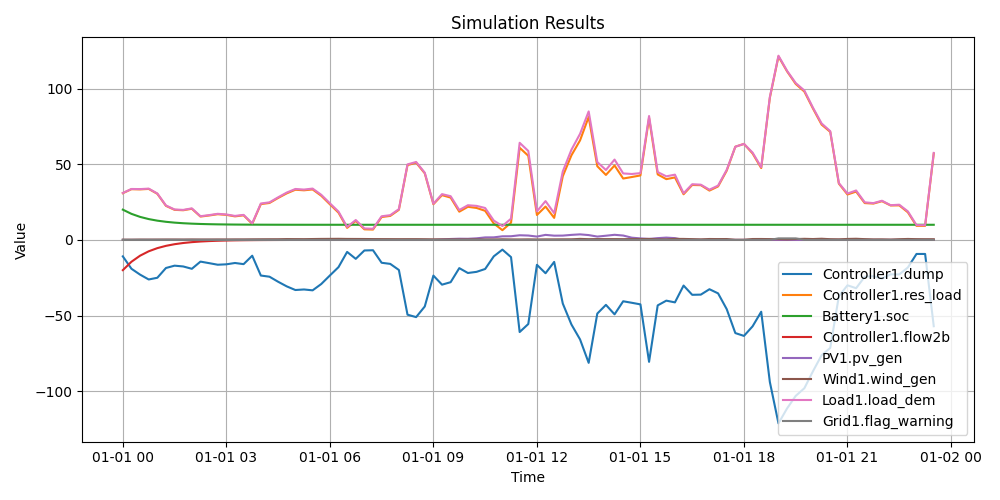

In [ ]:
#TODO: Fix flag visualisation
from tutorial5_funcs import *
plot_simulation_results()

### Evaluation
Let's look back on how our baseline scenario performed in CO2 & Grid Congestion, run the cell below to see the plot again!


⚠ Grid congestion detected!
   Congestion events: 3


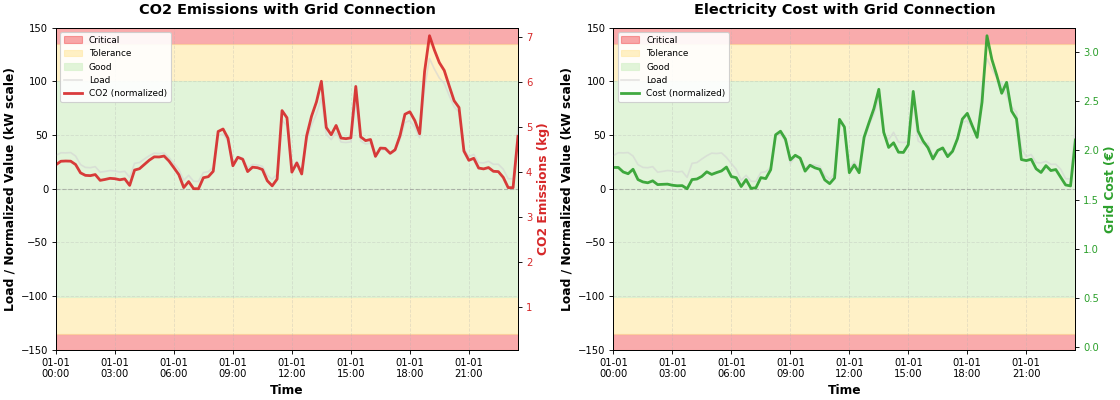

In [9]:
fig, (ax1, ax2) = plot_combined_analysis(
    co2_results_file='co2_results.csv',
    cost_results_file='electricity_cost_results.csv',
    consumption_file='out_Tutorial_5.csv',
    connection_cap=150,
    critical_limit=0.9,
    tolerance_limit=0.67,
    figsize=(14, 5)  # You can adjust this if needed
)

Now let's calculate our metrics for the renewables scenario we generated previously, run the cells below, then plot the values. What do you see?

In [10]:
# Calculate CO2 and costs for the new simulation output
co2_results = align_dates_and_calculate_co2(
    consumption_file='out_Tutorial_5_Green.csv',
    output_csv='co2_results_green.csv'
)

# Calculate electricity costs for the new simulation output
cost_results = calculate_electricity_cost(
    consumption_file='out_Tutorial_5_Green.csv',
    output_csv='electricity_cost_results_green.csv'
)


Total CO2 Emissions:        187.16 kg
                            0.19 tonnes
  Total Cost:               €72.61

✓ Results saved to: electricity_cost_results_green.csv



⚠ Grid congestion detected!
   Congestion events: 3


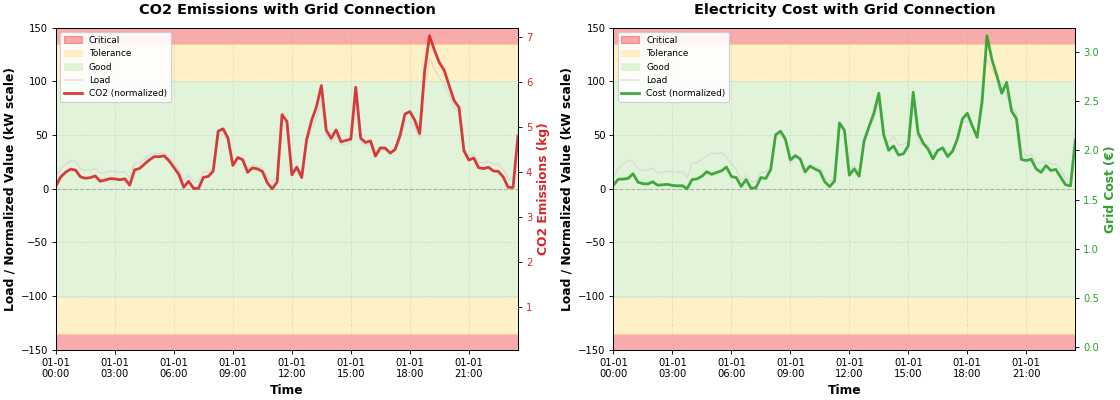

In [11]:
#TODO: negative cost should be plotted on negatives
#TODO: right now we assume that renewables have zero CO2 operational emissions

fig, (ax1, ax2) = plot_combined_analysis(
    co2_results_file='co2_results_green.csv',
    cost_results_file='electricity_cost_results_green.csv',
    consumption_file='out_Tutorial_5_Green.csv',
    connection_cap=150,
    critical_limit=0.9,
    tolerance_limit=0.67,
    figsize=(14, 5)  # You can adjust this if needed
)

THOUGHTS: 

- find days for which renewables STILL give grid warning
- introduce coordination
- households that get "points":
    - shift demand (flexible) (if we are talking about EH)
    - do not consume excessively
- justice agent accounts for these points in different ways?
- Final step, they play with a controller of their own using Jort's new function to import custom models
____________________________________________________________________________________________________________

- other tutorial could be: shared assets like storage, sae base yaml again, same setup but show that some days renewables are not enough to cover the peaks of demand but with coordination those peaks can be lowered (eg charging evs at different times), EH focus

In [12]:
# TODO: Why were there entirely new funcs for the same plots??

In [13]:
from renewable_electricity_cost_calculator2_improved4 import (
    calculate_renewable_and_grid_costs,
    plot_renewable_mix_costs,
    plot_cumulative_costs
)

In [14]:
# Your slider values
n_pv_panels = dashboard["pv_size_slider"].value      # Number of PV panels
n_wind_turbines = dashboard["n_t_slider"].value       # Number of wind turbines  
battery_capacity = dashboard["storage_slider"].value  # Battery capacity in kWh

# Your file paths
PRICE_FILE = 'data\GUI_ENERGY_PRICES_202511272300-202511282300.csv'
OUTPUT_FILE = 'out_Tutorial_Renewables.csv'

In [15]:
results = calculate_renewable_and_grid_costs(
    # Files
    price_file=PRICE_FILE,
    consumption_file=OUTPUT_FILE,
    renewable_output_file=OUTPUT_FILE,
    
    # Column names (adjust if different)
    consumption_column='Controller1.dump',
    pv_column='PV1.pv_gen',
    wind_column='Wind1.wind_gen',
    consumption_date_column='date',
    price_date_column='MTU (CET/CEST)',
    price_column='Day-ahead Price (EUR/MWh)',
    
    # System configuration (from sliders)
    n_pv=n_pv_panels,
    n_wind=n_wind_turbines,
    battery_capacity_kWh=battery_capacity,
    
    # LCOE parameters (defaults shown - adjust as needed)
    pv_cost_per_panel_EUR=800,
    pv_capacity_per_panel_kW=0.4,
    pv_lifetime_years=25,
    wind_cost_per_turbine_EUR=50000,
    wind_capacity_per_turbine_kW=10,
    wind_lifetime_years=20,
    battery_cost_per_kWh_EUR=600,
    battery_lifetime_years=10,
    discount_rate=0.05,
    
    # Output
    output_csv='./renewable_grid_cost_results.csv'
)


RENEWABLE AND GRID ELECTRICITY COST CALCULATION

Loading data files...
✓ Price data: 96 rows
✓ Consumption data: 95 rows
✓ Renewable generation data: 95 rows

Consumption starts at: 2012-02-01 00:00:00

Aligning price file dates to consumption dates...
✓ Price dates aligned

CALCULATING LEVELIZED COST OF ENERGY (LCOE)

Validating column names...
✓ PV column 'PV1.pv_gen' found
✓ Wind column 'Wind1.wind_gen' found

Simulation period: 0 days
Annualization factor: 1.00

--- CAPITAL COSTS ---
PV System (150 panels):           €120,000.00
Battery (200 kWh):         €120,000.00
TOTAL CAPITAL COST:                €240,000.00

--- PV LCOE ---
Annual generation:                 0 kWh/year
Lifetime:                          25 years
LCOE:                              €46815.8789/kWh
                                   €46815878.92/MWh

--- BATTERY STORAGE LCOE ---
Battery capacity:                  200 kWh
Lifetime:                          10 years
LCOE (allocated):                  €5366.6275/kW


PLOTTING RENEWABLE MIX ELECTRICITY COSTS
Grid costs - Positive periods: 0
Grid costs - Negative periods: 95
Grid costs - Min: -3.51, Max: -0.11
✓ Plotted compensation shading for 95 periods
✓ Plotted negative grid revenue: €65.70

✓ Plot saved to: renewable_mix_costs.png


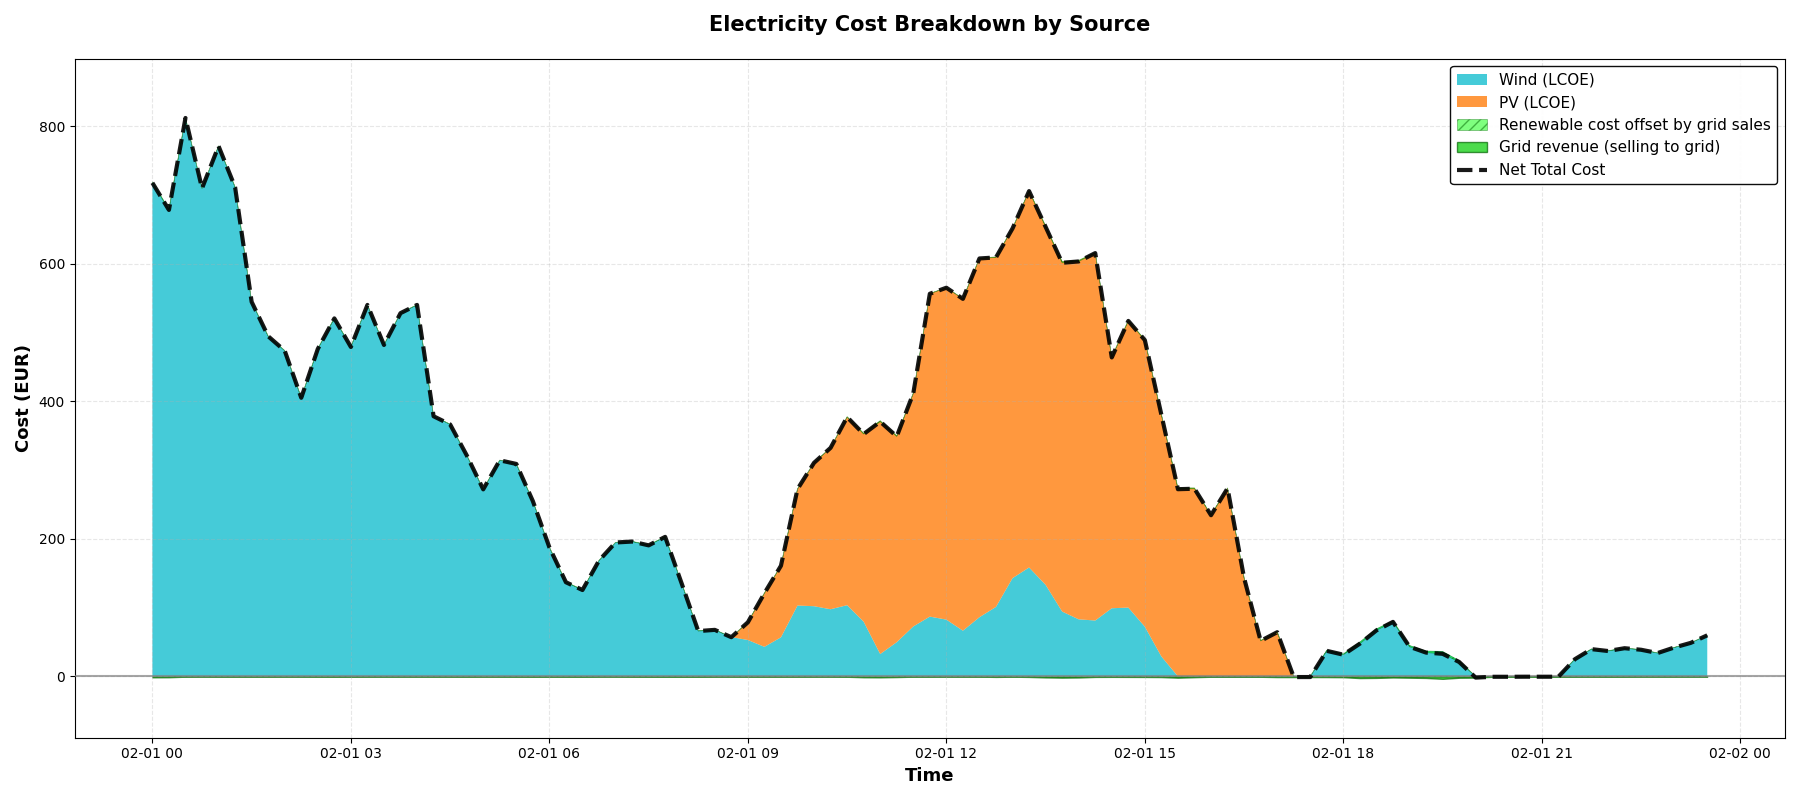


📊 Cost Statistics:
   Total Wind Cost:          €16,826.97
   Total PV Cost:            €10,827.87
   Total Renewable Cost:     €27,654.84
   Total Grid Cost (net):    €-65.70
     - Grid sales revenue:   €65.70
   Net Total Cost:           €27,589.14

💰 Negative Pricing Impact:
   Periods with negative pricing: 95
   Revenue from selling to grid:  €65.70
   Cost reduction from sales:     0.2% of renewable costs

✓ Plot displayed


In [16]:
# Plot 1: Renewable mix with stacked costs (different colors for each source)
plot_renewable_mix_costs(results)


Energy mix time dependent: https://transparency.entsoe.eu/generation/actual/perType/generation?appState=%7B%22sa%22%3A%5B%22BZN%7C10YNL----------L%22%5D%2C%22st%22%3A%22BZN%22%2C%22mm%22%3Atrue%2C%22ma%22%3Afalse%2C%22sp%22%3A%22HALF%22%2C%22dt%22%3A%22CHART%22%2C%22df%22%3A%5B%222026-01-15%22%2C%222026-01-15%22%5D%2C%22tz%22%3A%22CET%22%7D

Intraday day-ahead prices: https://transparency.entsoe.eu/market/energyPrices?appState=%7B%22sa%22%3A%5B%22BZN%7C10YNL----------L%22%5D%2C%22st%22%3A%22BZN%22%2C%22mm%22%3Atrue%2C%22ma%22%3Afalse%2C%22sp%22%3A%22HALF%22%2C%22dt%22%3A%22CHART%22%2C%22df%22%3A%222026-01-15%22%2C%22tz%22%3A%22CET%22%7D

Readjust the amount of PV's, wind and storage and evaluate the effect of your choice. The simulation results are stored in the pages here, page one has the results for the initial case with no renewables 